# 05 — Transaction Analysis
تحليل حجم وقيمة المعاملات حسب النوع والحالة والزمن.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROCESSED = Path('../data/processed')
OUT = Path('../visualizations/transactions')
OUT.mkdir(parents=True, exist_ok=True)
source = PROCESSED / 'cleaned_transactions.csv'
if not source.exists():
    source = PROCESSED / 'final_dataset.csv'
if not source.exists():
    raise FileNotFoundError('Run the cleaning notebook and create processed data first.')
df = pd.read_csv(source)

def find_column(candidates, required=True):
    column = next((c for c in candidates if c in df.columns), None)
    if required and column is None:
        raise KeyError(f'Expected one of {candidates}; available columns: {list(df.columns)}')
    return column

amount_col = find_column(['amount_usd', 'amount', 'transaction_amount', 'value'])
date_col = find_column(['transaction_date', 'date', 'created_at'])
type_col = find_column(['transaction_type', 'type'], required=False)
status_col = find_column(['transaction_status', 'status'], required=False)
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df = df[df[date_col].notna()].copy()
df['month'] = df[date_col].dt.to_period('M').astype(str)
print(f'Rows analyzed: {len(df)}')
last_ts = df[date_col].max()
partial_month = str(last_ts.to_period('M')) if last_ts.day < last_ts.days_in_month else None
print(f'Partial final month (excluded from trend charts): {partial_month}')


Rows analyzed: 476202
Partial final month (excluded from trend charts): 2026-10


In [2]:
group_cols = [c for c in [type_col, status_col] if c]
if group_cols:
    transaction_summary = df.groupby(group_cols).agg(
        transaction_count=(amount_col, 'size'),
        total_value=(amount_col, 'sum'),
        average_value=(amount_col, 'mean'),
        median_value=(amount_col, 'median')
    ).reset_index()
else:
    transaction_summary = pd.DataFrame([{'transaction_count': len(df), 'total_value': df[amount_col].sum(), 'average_value': df[amount_col].mean(), 'median_value': df[amount_col].median()}])
transaction_summary.to_csv(PROCESSED / 'transaction_summary.csv', index=False)
transaction_summary

# Native-currency view: never add these totals across currencies.
if 'currency' in df.columns and 'amount' in df.columns:
    currency_summary = df.groupby('currency').agg(transaction_count=('amount','size'), total_native_amount=('amount','sum'), total_amount_usd=(amount_col,'sum')).reset_index()
    currency_summary.to_csv(PROCESSED / 'currency_summary.csv', index=False)
    display(currency_summary)
transaction_summary

,currency,transaction_count,total_native_amount,total_amount_usd
0,EUR,98904,14337407.22,15484398.76
1,GBP,124277,16907107.73,21472028.88
2,USD,253021,38721948.21,38721948.21


,transaction_type,transaction_status,transaction_count,total_value,average_value,median_value
0,Deposit,Completed,7791,36160291.88,4641.290191,3579.930
1,Transfer,Completed,8616,6653666.56,772.245422,473.265
2,Withdrawal,Completed,459795,32864417.41,71.476239,28.940


In [3]:
monthly = df.groupby('month').agg(
    transaction_count=(amount_col, 'size'),
    total_value=(amount_col, 'sum'),
    average_value=(amount_col, 'mean')
).reset_index()
monthly['is_partial_month'] = monthly['month'].eq(partial_month)
monthly.to_csv(PROCESSED / 'monthly_transaction_summary.csv', index=False)
monthly.head()

,month,transaction_count,total_value,average_value,is_partial_month
0,2023-10,14623,1796358.94,122.844761,False
1,2023-11,15595,2107463.54,135.137130,False
2,2023-12,14528,2061161.40,141.875096,False
3,2024-01,14232,2118839.73,148.878565,False
4,2024-02,12621,1986077.54,157.362930,False


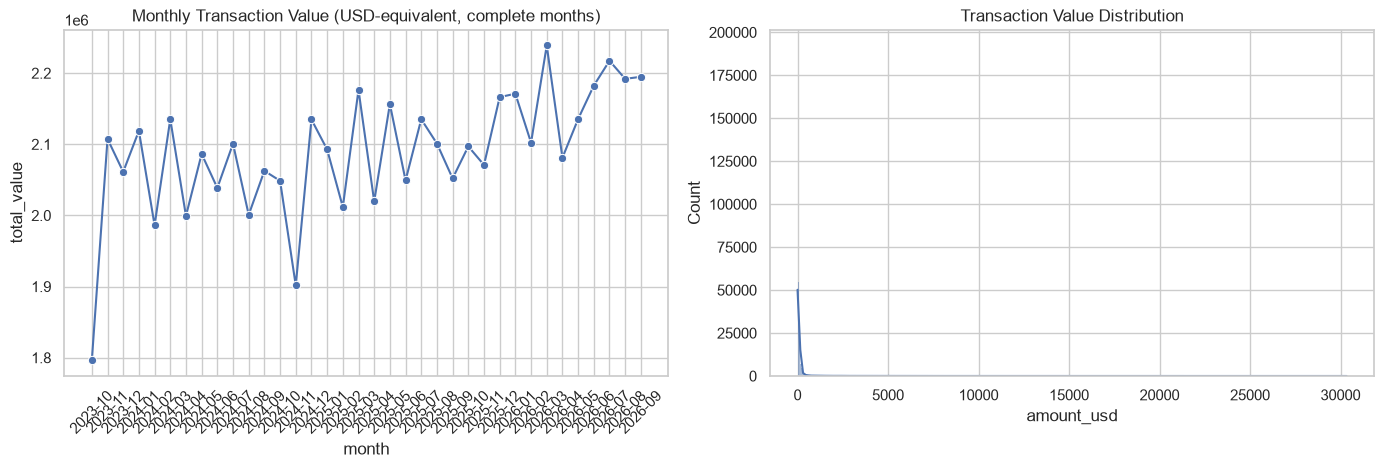

In [4]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=monthly[~monthly['is_partial_month']], x='month', y='total_value', marker='o', ax=axes[0])
axes[0].set_title('Monthly Transaction Value (USD-equivalent, complete months)')
axes[0].tick_params(axis='x', rotation=45)
sns.histplot(df[amount_col].dropna(), kde=True, ax=axes[1])
axes[1].set_title('Transaction Value Distribution')
fig.tight_layout()
fig.savefig(OUT / 'transaction_trend_and_distribution.png', dpi=150)
plt.show()
plt.close(fig)

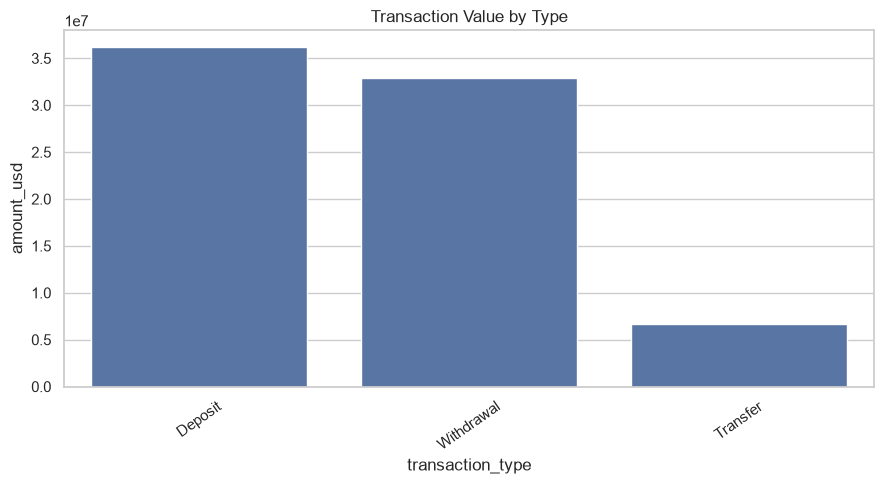

In [5]:
if type_col:
    fig, ax = plt.subplots(figsize=(9, 5))
    order = df.groupby(type_col)[amount_col].sum().sort_values(ascending=False).index
    sns.barplot(data=df, x=type_col, y=amount_col, estimator='sum', errorbar=None, order=order, ax=ax)
    ax.set_title('Transaction Value by Type')
    ax.tick_params(axis='x', rotation=35)
    fig.tight_layout()
    fig.savefig(OUT / 'transaction_value_by_type.png', dpi=150)
    plt.show()
    plt.close(fig)

## Interpretation checklist
- افصل بين transaction count وtransaction value.
- راجع أثر المعاملات الفاشلة أو المعكوسة قبل حساب التدفقات المالية.
- افحص الأيام أو الأشهر ذات النشاط غير المعتاد.
- لا تستنتج سبب التغير الزمني من الرسم وحده.